In [1]:
# imports
import os
import pandas as pd
import numpy as np
import json
import random 
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import re
import glob
from TrackReconstruction_functions import *
import sys
from io import StringIO


In [2]:
file = "/home/rei/NEXT/vertex_ML/analysis/test_h5/events_45_135_0.1percent_smear_999.h5"
diffusion = "0.1percent"
pressure = 1
event_type = "events_45_135"
eid = 120000

part_df = pd.read_hdf(file, "MC/particles")
hits_df = pd.read_hdf(file, "MC/hits")

part_df.head()

,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,...,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
0,120000,2,e-,1,0,762.778320,-1662.611450,1714.886108,0.000000,522.046021,...,-1.811962,-0.413822,0.351119,0.0,-0.0,-0.0,1.448302,2126.193848,none,eIoni
1,120000,152,e-,0,2,522.046875,-1494.111816,619.361328,8.004511,522.046326,...,-0.003157,0.004719,0.001308,-0.0,0.0,0.0,0.000033,0.000940,eIoni,msc
2,120000,151,e-,0,2,522.046875,-1494.111816,619.361328,8.004511,522.047241,...,0.002524,-0.005981,-0.002175,-0.0,-0.0,0.0,0.000046,0.001002,eIoni,msc
3,120000,150,e-,0,2,522.046875,-1494.111816,619.361328,8.004511,522.047607,...,0.004021,-0.004004,-0.000563,-0.0,-0.0,-0.0,0.000032,0.001317,eIoni,msc
4,120000,149,e-,0,2,522.046875,-1494.111816,619.361328,8.004511,522.046570,...,-0.001429,-0.002274,0.003988,-0.0,-0.0,0.0,0.000023,0.001933,eIoni,eIoni


In [3]:
def get_zshift(pressure):
    density = 5.987*pressure
    M = 1000/0.9
    det_size = 1000*np.cbrt((4 * M) / (np.pi * density))/2.0

    return det_size

z_shift = get_zshift(1)

### True Data

In [4]:
#-----GET VERTEX------
def get_vertex(part, eid):

    x_vertex = part[(part.event_id == eid) & (part.particle_id == 1)].initial_x.iloc[0]
    y_vertex = part[(part.event_id == eid) & (part.particle_id == 1)].initial_y.iloc[0]
    z_vertex = part[(part.event_id == eid) & (part.particle_id == 1)].initial_z.iloc[0]

    return x_vertex, y_vertex, z_vertex

In [5]:
vertex = get_vertex(part_df, eid)
print(vertex)

(np.float32(762.7783), np.float32(-1662.6115), np.float32(1714.8861))


In [6]:
def get_true_angle(part, eid):
    p_x1 = part[(part.event_id == eid) & (part.particle_id == 1)].initial_momentum_x.iloc[0]
    p_y1 = part[(part.event_id == eid) & (part.particle_id == 1)].initial_momentum_y.iloc[0]
    p_z1 = part[(part.event_id == eid) & (part.particle_id == 1)].initial_momentum_z.iloc[0]
    
    p_x2 = part[(part.event_id == eid) & (part.particle_id == 2)].initial_momentum_x.iloc[0]
    p_y2 = part[(part.event_id == eid) & (part.particle_id == 2)].initial_momentum_y.iloc[0]
    p_z2 = part[(part.event_id == eid) & (part.particle_id == 2)].initial_momentum_z.iloc[0]
    
    cos12 = ((p_x1 * p_x2) + (p_y1 * p_y2) + (p_z1 * p_z2))/(np.sqrt((p_x1 ** 2) + (p_y1 ** 2) + (p_z1 ** 2)) * np.sqrt((p_x2 ** 2) + (p_y2 ** 2) + (p_z2 ** 2)))
    return cos12

In [7]:
cos12_true = get_true_angle(part_df, eid)
print(cos12_true)

-0.2879097


In [8]:
def get_true_e_vectors(eid, part_df, vertex, particle_ids=[1,2]):
    vertex = np.array(vertex, dtype=float)
    
    vectors=[]

    for pid in particle_ids:
        row = part_df[(part_df.event_id==eid) & (part_df.particle_id==pid)].iloc[0]

        p = np.array([row.initial_momentum_x, row.initial_momentum_y, row.initial_momentum_z], dtype=float)

        #unit dir
        direction = p / np.linalg.norm(p)

        endpoint = vertex + direction

        vectors.append((endpoint, direction))

    vectors = [
        {"endpoint": vec[0].tolist(), "direction": vec[1].tolist()}
        for vec in vectors
        ]

    return vectors

In [9]:
vectors = get_true_e_vectors(eid, part_df, vertex)
print(vectors)

[{'endpoint': [762.9439308754796, -1662.835500948074, 1713.925705148955], 'direction': [0.16561056297961527, -0.22405075276156008, -0.9604032494825042]}, {'endpoint': [761.8203661858661, -1662.830231134469, 1715.0717391930993], 'direction': [-0.957954126633975, -0.21878093915632577, 0.18563079466191607]}]


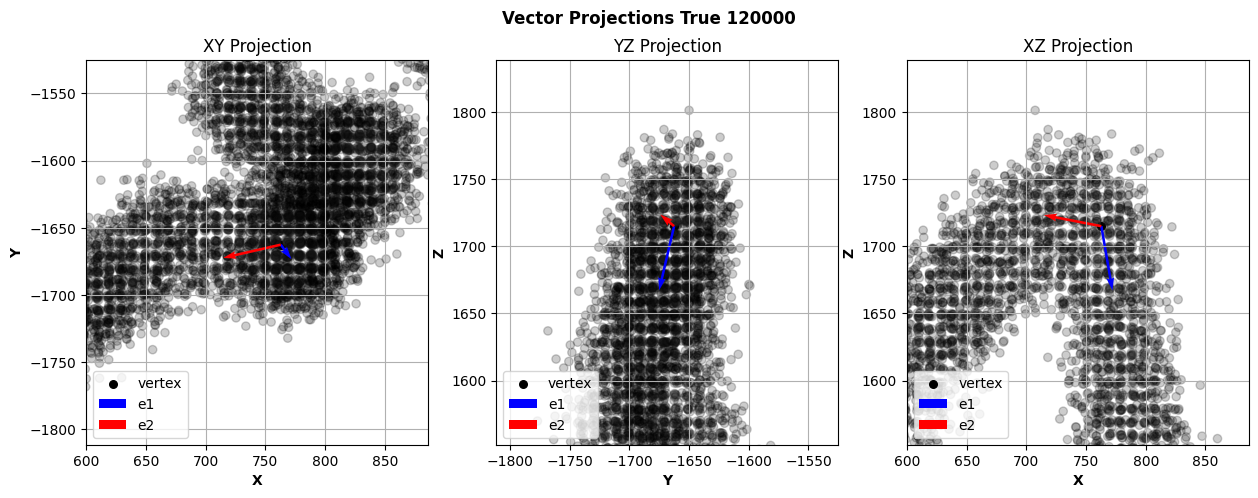

In [10]:
# plot true

x_vertex, y_vertex, z_vertex = vertex[0], vertex[1], vertex[2]
p1, p2 = vectors[0]["direction"], vectors[1]["direction"]

scale_factor = 50  # Adjust this to make arrows longer or shorter

p1 = [scale_factor * comp for comp in p1]
p2 = [scale_factor * comp for comp in p2]


event_hits = hits_df[hits_df.event_id == eid].copy()
event_hits["z"] = event_hits["z"]-z_shift

indices = np.arange(len(event_hits))

# getting axis range
    
xs = [x_vertex, x_vertex + p1[0], x_vertex + p2[0]]
ys = [y_vertex, y_vertex + p1[1], y_vertex + p2[1]]
zs = [z_vertex, z_vertex + p1[2], z_vertex + p2[2]]


#min/max
xmin, xmax = min(xs), max(xs)
ymin, ymax = min(ys), max(ys)
zmin, zmax = min(zs), max(zs)

#ranges = and padded
max_range = max(xmax-xmin, ymax-ymin, zmax-zmin)
pad = 2 * max_range #20% padding

xmid = (xmax + xmin) / 2 
ymid = (ymax + ymin) / 2
zmid = (zmax + zmin) / 2

xlims = (xmid - max_range/2 - pad, xmid + max_range/2 + pad)
ylims = (ymid - max_range/2 - pad, ymid + max_range/2 + pad)
zlims = (zmid - max_range/2 - pad, zmid + max_range/2 + pad)

fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

#XY projection
ax1.scatter(x_vertex, y_vertex, color = "black", s=30, label="vertex")
ax1.scatter(event_hits.x, event_hits.y, alpha=0.2, c=event_hits.energy, cmap="Greys_r")
ax1.quiver(x_vertex, y_vertex, p1[0], p1[1], color="blue", label="e1", scale_units="xy", scale=1)
ax1.quiver(x_vertex, y_vertex, p2[0], p2[1], color="red", label="e2", scale_units="xy", scale=1)
ax1.set_xlim(xlims)
ax1.set_ylim(ylims)
ax1.set_xlabel("X", fontweight="bold")
ax1.set_ylabel("Y", fontweight="bold")
ax1.set_title("XY Projection")
ax1.legend(loc="lower left")
ax1.grid(True)
    
#YZ projection
ax2.scatter(y_vertex, z_vertex, color = "black", s=30, label="vertex")
ax2.scatter(event_hits.y, event_hits.z, alpha=0.2, c=event_hits.energy, cmap="Greys_r")
ax2.quiver(y_vertex, z_vertex, p1[1], p1[2], color="blue", label="e1", scale_units="xy", scale=1)
ax2.quiver(y_vertex, z_vertex, p2[1], p2[2], color="red", label="e2", scale_units="xy", scale=1)
ax2.set_xlim(ylims)
ax2.set_ylim(zlims)
ax2.set_xlabel("Y", fontweight="bold")
ax2.set_ylabel("Z", fontweight="bold")
ax2.set_title("YZ Projection")
ax2.legend(loc="lower left")
ax2.grid(True)

#XZ projection
ax3.scatter(x_vertex, z_vertex, color = "black", s=30, label="vertex")
ax3.scatter(event_hits.x, event_hits.z, alpha=0.2, c=event_hits.energy, cmap="Greys_r")
ax3.quiver(x_vertex, z_vertex, p1[0], p1[2], color="blue", label="e1", scale_units="xy", scale=1)
ax3.quiver(x_vertex, z_vertex, p2[0], p2[2], color="red", label="e2", scale_units="xy", scale=1)
ax3.set_xlim(xlims)
ax3.set_ylim(zlims)
ax3.set_xlabel("X", fontweight="bold")
ax3.set_ylabel("Z", fontweight="bold")
ax3.set_title("XZ Projection")
ax3.legend(loc="lower left")
ax3.grid(True)

fig.suptitle(f"Vector Projections True {eid}", fontweight="bold")

plt.show()

### Reco Data (From True Vertex)

In [11]:
def get_node_centers_df(hits_df, eid, pressure, diffusion, diff_scale_change):
    #print(f"diffusion: {diffusion}")
    #print(f"pressure: {pressure}")
    data = hits_df[hits_df["event_id"] == int(eid)].copy()
    if np.isnan(data.z.mean()) or data.z.empty:
        print(f"Skipping event {eid} because hits are missing or invalid")
        return pd.DataFrame()
    #print(pressure, type(pressure))
    #print(diffusion, type(diffusion))
    Diff_smear, energy_threshold, diff_scale_factor, radius_sf, group_sf, Tortuosity_dist, voxel_size, det_size  = InitializeParams(pressure, diffusion)
    # voxel_sf=1.1
    # energy_threshold=0
    # energy_threshold = 0.0004
    #diff_scale_factor = diff_scale_change
    """
    print("Diffussion smear is: ",        Diff_smear,            "mm/sqrt(cm)")
    print("Energy threshold is: ",        1000*energy_threshold, "keV")
    print("diffision scale factor is: ",  diff_scale_factor)
    print("Radius scale factor is: ",     radius_sf)
    print("Hit grouping factor is: ",     group_sf)
    print("Tortuosity distance scale is:", Tortuosity_dist)
    print("The voxel size is:",           voxel_size)
    print("The det_size is", det_size)
    """
    #print(f"diffusion: {diffusion}")
    if (diffusion == "next1t"):
        mean_sigma=6
    elif (diffusion == "nodiff"):
        #print(f"check diffusion: {diffusion}")
        mean_sigma=10/np.sqrt(pressure)
        #print(f"check mean sigma: {mean_sigma}")
    else:
        if data.z.mean() < 0:
            print("skipping event, invalid data.z.mean()")
            return None, None
        mean_sigma = diff_scale_factor*Diff_smear*np.sqrt(0.1*data.z.mean())

    # The expected diffusion is less than vox size so replace
    if (mean_sigma < 1.5*voxel_size):
        mean_sigma = 1.5*voxel_size
    
    # Create the bins ---- 
    xbw  = mean_sigma
    xmin = -det_size - mean_sigma/2 
    xmax = det_size  + mean_sigma/2
    
    ybw  = mean_sigma
    ymin = -det_size - mean_sigma/2 
    ymax = det_size  + mean_sigma/2
    
    # This shifts the z pos of the events so 0 is at anode
    # can set this to zero
    #z_shift = det_size
    z_shift = 0
    
    zbw=mean_sigma
    zmin=-det_size + z_shift - mean_sigma/2 
    zmax=det_size + z_shift + mean_sigma/2

    # bins for x, y, z
    xbins = np.arange(xmin, xmax+xbw, xbw)
    ybins = np.arange(ymin, ymax+ybw, ybw)
    zbins = np.arange(zmin, zmax+zbw, zbw)
    
    # center bins for x, y, z
    xbin_c = xbins[:-1] + xbw / 2
    ybin_c = ybins[:-1] + ybw / 2
    zbin_c = zbins[:-1] + zbw / 2

    # If there are overlapping voxels, merge them. Otherwise the energy gets messed up
    data = (data.groupby(["event_id", "x", "y", "z"], as_index=False)["energy"].sum())
    # then sort it based on the x,y,z
    data = data.sort_values(by=['x', "y", "z"]).reset_index(drop=True)
    """
    print(f"xmin: {xmin}, xmax: {xmax}, xbw: {xbw}")
    print(f"ymin: {ymin}, ymax: {ymax}, ybw: {ybw}")
    print(f"zmin: {zmin}, zmax: {zmax}, zbw: {zbw}")
    
    print(f"data x range: {data['x'].min()} to {data['x'].max()}")
    print(f"data y range: {data['y'].min()} to {data['y'].max()}")
    print(f"data z range: {data['z'].min()} to {data['z'].max()}")
    """
    # Apply grouping
    data_copy = data.copy()
    #df_merged = CutandRedistibuteEnergy(data_copy, energy_threshold)
    print("applied grouping")

    
    
    if diffusion == "next1t":
        mean_sigma_group = 10
    elif (diffusion == "nodiff"):
        #print(f"diffusion: {diffusion}")
        mean_sigma_group=15
    else:
        mean_sigma_group = group_sf*Diff_smear*np.sqrt(0.1*data.z.mean())

    if (mean_sigma_group < voxel_size/2.0):
        mean_sigma_group = voxel_size/2.0
        """
    print("Mean sigma group", mean_sigma_group)
    print("Number of hits:", len(data))
    print("Mean z:", data.z.mean(), " diffusion = ", mean_sigma)
    print("Mean Sigma: ", mean_sigma)
    """
    print("Mean sigma group:", mean_sigma_group)

    
    df_merged = GroupHits(data_copy, mean_sigma_group)
    #print(f"df_merged: {df_merged.group_id.unique()}")
    # Apply clustering
    node_centers_df = []
    energy_gid_dict = {}
    for gid in sorted(df_merged.group_id.unique()):
        #print(f"applying clustering for {gid}")
        temp_df = df_merged[df_merged.group_id == gid]
        energy_sum = temp_df["energy"].sum()
        energy_gid_dict[gid] = energy_sum
        temp_df.reset_index(drop=True, inplace=True)
        node_centers_df.append(Cluster(temp_df, mean_sigma))
    max_energy_gid = max(energy_gid_dict, key=energy_gid_dict.get)
    node_centers_df = pd.concat(node_centers_df, ignore_index=True)
    node_centers_df = node_centers_df[node_centers_df.group_id == max_energy_gid]
    #print("COMPLETED NODE CENTERS DF")
    return node_centers_df


In [12]:
def get_reco_e_vectors(hits_df, part_df, eid, N, diffusion, pressure, z_shift, diff_scale_change, vertex=None, plot=False):

    node_centers_df = get_node_centers_df(hits_df, eid, pressure, diffusion, diff_scale_change)
    df = node_centers_df.copy() 
    if diffusion != "nodiff":
        df["z"] = df["z"] - z_shift
        print("Subtracted z shift")
    
    if vertex is None:
        vertex = get_vertex(part_df, eid)
    else:
        vertex = vertex

    
    hits = df[["x", "y", "z"]].values

    
    dists = np.linalg.norm(hits - vertex, axis=1)
    N=N #cluster hits total
    closest_hits = hits[np.argsort(dists)[:N]] # sort by dist
    hits_from_vertex = closest_hits - vertex # use vertex as reference
    radii = np.linalg.norm(hits_from_vertex, axis=1)

    # keep only hits that are not at the vertex
    mask = radii > 15 #events <1mm from vertex are not used
    hits_from_vertex = hits_from_vertex[mask]
    closest_hits = closest_hits[mask]
    radii = radii[mask]

    if len(radii)<2:
        print("Not enough hits to cluster")
        return[]
    # normalize
    directions = hits_from_vertex / radii[:, None]
    
    kmeans = KMeans(n_clusters=2, random_state=0).fit(directions) # 2 clusters
    labels = kmeans.labels_
    
    vectors = []
    for cluster_id in [0,1]:
        cluster_hits = closest_hits[labels == cluster_id] #cluster hits
    
        if len(cluster_hits) == 0:
            print("Not enough hits")
            continue
            
        #get vectors
        dists = np.linalg.norm(cluster_hits - vertex, axis=1) 
        endpoint = cluster_hits[np.argmin(dists)]
        direction_vector = endpoint - vertex
        vectors.append((endpoint, direction_vector))

    event_hits = hits_df[hits_df.event_id == eid]

    # plot clustered hits
    if plot == True:
        vertex_true = get_vertex(part_df, eid)
        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection="3d")
        part_1 = part_df[(part_df.event_id == eid) & (part_df.particle_id == 1)]
        part_2 = part_df[(part_df.event_id == eid) & (part_df.particle_id == 2)]
    
        p1 = part_1[['initial_momentum_x', 'initial_momentum_y', 'initial_momentum_z']].values.flatten()
        p2 = part_2[['initial_momentum_x', 'initial_momentum_y', 'initial_momentum_z']].values.flatten()    
        colors = ["red", "blue"]
            
        for cluster_id in [0, 1]:
            cluster_hits = closest_hits[labels == cluster_id]
            ax.scatter(cluster_hits[:, 0], cluster_hits[:, 1], cluster_hits[:, 2],
                           label=f"Cluster {cluster_id}", color=colors[cluster_id], s=40)
    
        ax.scatter(vertex[0], vertex[1], vertex[2], color="black", s=60, label="Vertex Smeared")
        ax.scatter(vertex_true[0], vertex_true[1], vertex_true[2], color="green", s=60, label="Vertex")
            #ax.scatter(event_hits["x"], event_hits["y"], event_hits["z"], color="black", alpha=0.1, s=30)
        ax.scatter(df["x"], df["y"], df["z"], color="purple", marker="+", alpha=0.5)
        ax.quiver(vertex[0], vertex[1], vertex[2], vectors[0][1][0], vectors[0][1][1], vectors[0][1][2], label="reco", color="black")
        ax.quiver(vertex[0], vertex[1], vertex[2], vectors[1][1][0], vectors[1][1][1], vectors[1][1][2], color="black")
        ax.quiver(vertex_true[0], vertex_true[1], vertex_true[2], p1[0], p1[1], p1[2], length=10, label="true", color="purple")
        ax.quiver(vertex_true[0], vertex_true[1], vertex_true[2], p2[0], p2[1], p2[2], length=10, color="purple")
        ax.legend()
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        ax.set_xlim((vertex[0] - 50), (vertex[0] + 50))
        ax.set_ylim((vertex[1] - 50), (vertex[1] + 50))
        ax.set_zlim((vertex[2] - 50), (vertex[2] + 50))
        ax.set_title("KMeans Clustering of Hits")
    
        plt.show()

    vectors = [
        {"endpoint": vec[0].tolist(), "direction": vec[1].tolist()}
        for vec in vectors
        ]
    
    return vectors

applied grouping
Mean sigma group: 61.686756
Subtracted z shift


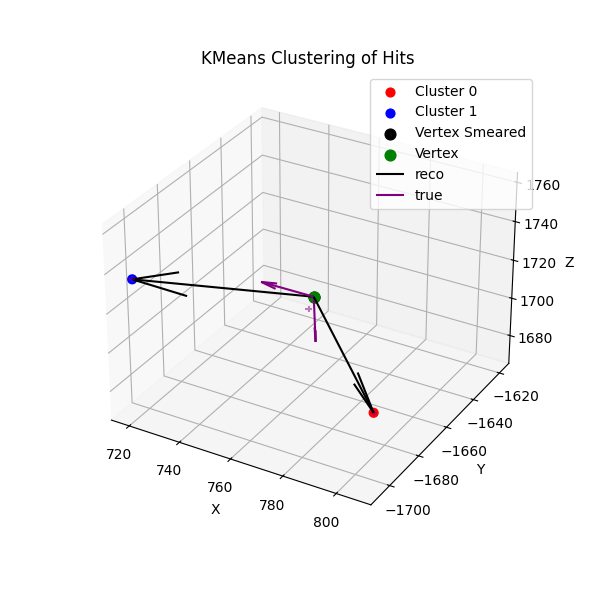

[{'endpoint': [803.9044799804688, -1695.210693359375, 1694.848303285236],
  'direction': [41.12615966796875, -32.5992431640625, -20.037805113201557]},
 {'endpoint': [688.468017578125, -1661.860595703125, 1695.237463441486],
  'direction': [-74.310302734375, 0.7508544921875, -19.648644956951557]}]

In [13]:
%matplotlib widget
get_reco_e_vectors(hits_df, part_df, eid, 10, diffusion, pressure, z_shift, 8, vertex=vertex, plot=True)

In [13]:
def get_true_angle(eid, part):
    p_x1 = part[(part.event_id == eid) & (part.particle_id == 1)].initial_momentum_x.iloc[0]
    p_y1 = part[(part.event_id == eid) & (part.particle_id == 1)].initial_momentum_y.iloc[0]
    p_z1 = part[(part.event_id == eid) & (part.particle_id == 1)].initial_momentum_z.iloc[0]
    
    p_x2 = part[(part.event_id == eid) & (part.particle_id == 2)].initial_momentum_x.iloc[0]
    p_y2 = part[(part.event_id == eid) & (part.particle_id == 2)].initial_momentum_y.iloc[0]
    p_z2 = part[(part.event_id == eid) & (part.particle_id == 2)].initial_momentum_z.iloc[0]
    
    cos12 = ((p_x1 * p_x2) + (p_y1 * p_y2) + (p_z1 * p_z2))/(np.sqrt((p_x1 ** 2) + (p_y1 ** 2) + (p_z1 ** 2)) * np.sqrt((p_x2 ** 2) + (p_y2 ** 2) + (p_z2 ** 2)))
    return cos12

### Reco Data (From Smeared Vertex)

In [14]:
def add_smear(part_df, eid, smear):
    vertex = get_vertex(part_df, eid)
        
    phi = np.random.uniform(0, 2*np.pi)
    costheta = np.random.uniform(-1, 1)
    theta = np.arccos(costheta)
                    
    r = smear
    
    x_new = vertex[0] + r * np.sin(theta) * np.cos(phi)
    y_new = vertex[1] + r * np.sin(theta) * np.sin(phi)
    z_new = vertex[2] + r * np.cos(theta)
    
    vertex_smeared = np.array([x_new, y_new, z_new])

    return vertex_smeared

### Testing json output files

In [15]:
nodiff_full_df = pd.read_json("/home/rei/NEXT/vertex_ML/analysis/nodiff_full.jsonl", lines=True)
five_full_df = pd.read_json("/home/rei/NEXT/vertex_ML/analysis/5.0percent_full.jsonl", lines=True)
zero_one_full_df = pd.read_json("/home/rei/NEXT/vertex_ML/analysis/0.1percent_full.jsonl", lines=True)

nodiff_full_df.head()

,file,event_id,vertex,energies,vectors_true,cos12_true,vectors_reco,cos12_reco,vertex_1mm,vectors_1mm,...,cos12_2mm,vertex_3mm,vectors_3mm,cos12_3mm,vertex_4mm,vectors_4mm,cos12_4mm,vertex_5mm,vectors_5mm,cos12_5mm
0,events_45_135_nexus_234.h5,28200,"[89.17036437988281, -254.9182891845703, 770.67...","[1.781910896301269, 1.218094229698181]","[{'endpoint': [89.00848481290471, -254.4816803...",-0.454866,"[{'endpoint': [79.4565200805664, -257.61080932...",-0.487951,"[88.86144002208489, -255.10006462982318, 769.7...","[{'endpoint': [79.4565200805664, -257.61080932...",...,-0.618403,"[91.09571450968498, -252.8572828947578, 771.69...","[{'endpoint': [79.4565200805664, -257.61080932...",-0.224220,"[87.67924110127412, -258.12826677466614, 768.8...","[{'endpoint': [79.4565200805664, -257.61080932...",-0.563375,"[91.24455884378584, -250.36886987136333, 770.6...","[{'endpoint': [79.4565200805664, -257.61080932...",-0.181575
1,events_45_135_nexus_234.h5,28201,"[-54.74333572387695, -2966.484619140625, 1998....","[1.379248261451721, 1.6207501888275142]","[{'endpoint': [-55.02584569747405, -2965.93378...",0.454660,"[{'endpoint': [-45.209869384765625, -2955.6706...",0.492365,"[-54.91854858746494, -2966.686053230591, 1999....","[{'endpoint': [-45.209869384765625, -2955.6706...",...,0.407536,"[-56.511926764574234, -2965.4762509016687, 199...","[{'endpoint': [-45.209869384765625, -2955.6706...",0.539460,"[-53.57113195968768, -2963.9692040412474, 2001...","[{'endpoint': [-45.209869384765625, -2955.6706...",0.248632,"[-53.12605900646379, -2966.173092952516, 1993....","[{'endpoint': [-57.89631652832031, -2961.35180...",0.623635
2,events_45_135_nexus_234.h5,28202,"[314.8579406738281, 2711.10498046875, -552.675...","[1.730754613876342, 1.269249081611633]","[{'endpoint': [315.17700085837276, 2710.841630...",0.901132,"[{'endpoint': [318.6174011230469, 2706.1215820...",0.977016,"[314.98840423433916, 2711.7930282911852, -551....","[{'endpoint': [318.6174011230469, 2706.1215820...",...,0.962188,"[314.8621330057856, 2710.2448115933494, -549.8...","[{'endpoint': [318.6174011230469, 2706.1215820...",0.959663,"[311.09715809001284, 2712.4640880362854, -552....","[{'endpoint': [319.6283874511719, 2705.7192382...",0.959133,"[313.05188592239057, 2715.531212507787, -554.1...","[{'endpoint': [319.6283874511719, 2705.7192382...",0.905683
3,events_45_135_nexus_234.h5,28203,"[373.4661560058594, 349.9651794433594, -638.76...","[1.362069845199585, 1.637934684753418]","[{'endpoint': [373.3819762052033, 349.98017940...",-0.087843,"[{'endpoint': [362.6803894042969, 367.66485595...",-0.100428,"[372.5930854145892, 349.886021190455, -638.283...","[{'endpoint': [362.6803894042969, 367.66485595...",...,0.040092,"[372.07618050437156, 350.1919811462794, -636.1...","[{'endpoint': [362.6803894042969, 367.66485595...",-0.053132,"[372.2966744914987, 349.7984995025873, -634.94...","[{'endpoint': [362.6803894042969, 367.66485595...",0.036802,"[376.15421895038344, 346.51332284672463, -636....","[{'endpoint': [370.51177978515625, 354.9004516...",0.497040
4,events_45_135_nexus_234.h5,28204,"[-115.1897201538086, 1587.96142578125, -2769.7...","[1.736728310585022, 1.263268947601318]","[{'endpoint': [-115.11645010723716, 1587.47077...",-0.290744,"[{'endpoint': [-112.67630767822266, 1581.93530...",-0.228110,"[-115.20885679729112, 1587.5336735901299, -276...","[{'endpoint': [-112.67630767822266, 1581.93530...",...,-0.280238,"[-114.42494850108008, 1590.188371065965, -2771...","[{'endpoint': [-101.98085021972656, 1599.75476...",-0.193759,"[-115.00556518099947, 1585.3430816315845, -276...","[{'endpoint': [-112.67630767822266, 1581.93530...",-0.308333,"[-112.91921230855671, 1587.1515403465978, -277...","[{'endpoint': [-101.98085021972656, 1599.75476...",-0.042227


In [16]:
print(len(nodiff_full_df))
print(len(five_full_df))
print(len(zero_one_full_df))

109440
104280
95400


### Plots

#### Angle Difference

In [17]:
def plot_diff_smear(df, smears, bins, title):
    bins_array = np.linspace(-5, 5, bins)
    n = len(smears) + 1  # +1 for true vertex
    cmap = plt.get_cmap("viridis")
    colors = [cmap(i / (n - 1)) for i in range(n)]
    plt.figure(figsize=(6,6))

    for idx, smear in enumerate(smears):
        smear_angle_diff = df[f"cos12_true"] - df[f"cos12_{smear}mm"]
        plt.hist(smear_angle_diff, bins=bins_array, color=colors[idx], histtype="step", label=f"{smear}mm smear")

    angle_res = (df[f"cos12_true"] - df[f"cos12_reco"])
    plt.hist(angle_res, bins=bins_array, color="black", histtype="step", linestyle="--", label="true vertex")

    plt.xlim(-2, 2)
    plt.xlabel("reco - true")
    plt.ylabel("events")
    plt.legend()
    plt.title(title)
    plt.show()

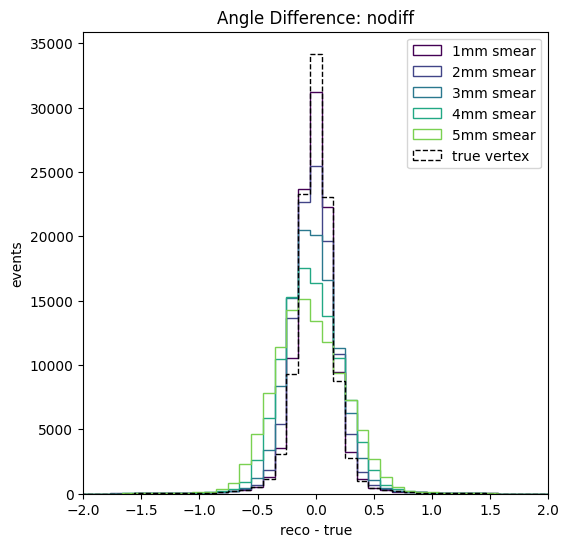

In [18]:
plot_diff_smear(nodiff_full_df, [1,2,3,4,5], 100, "Angle Difference: nodiff")

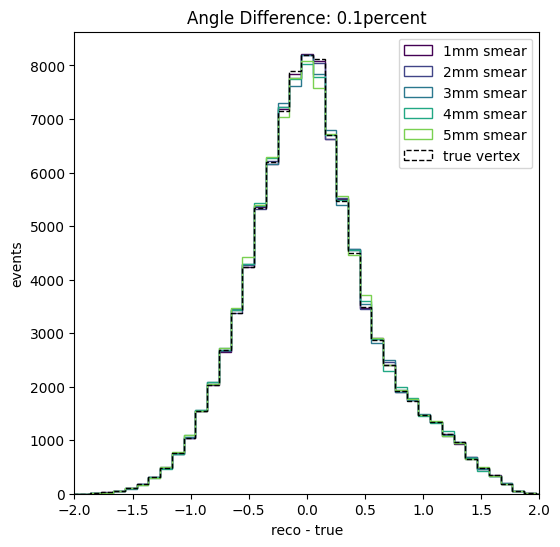

In [19]:
plot_diff_smear(zero_one_full_df, [1,2,3,4,5], 100, "Angle Difference: 0.1percent")

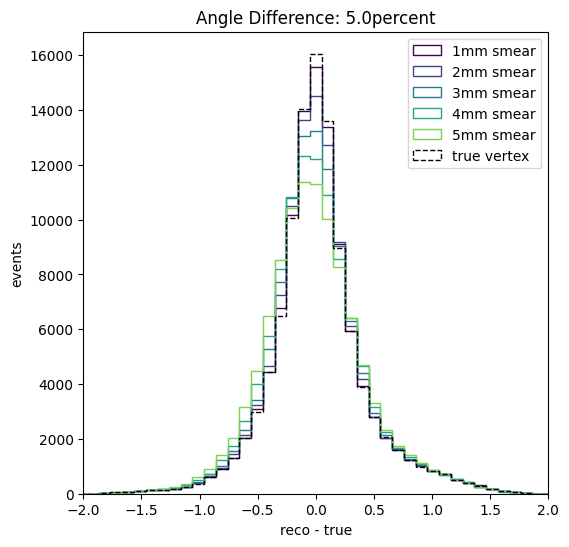

In [20]:
plot_diff_smear(five_full_df, [1,2,3,4,5], 100, "Angle Difference: 5.0percent")

In [21]:
E11 = nodiff_full_df["energies"].str[0]
E21 = nodiff_full_df["energies"].str[1]

nodiff_full_df["asymmetry"] = (E11 - E21) / (E11 + E21)

E12 = zero_one_full_df["energies"].str[0]
E22 = zero_one_full_df["energies"].str[1]

zero_one_full_df["asymmetry"] = (E12 - E22) / (E12 + E22)

E13 = five_full_df["energies"].str[0]
E23 = five_full_df["energies"].str[1]

five_full_df["asymmetry"] = (E13 - E23) / (E13 + E23)

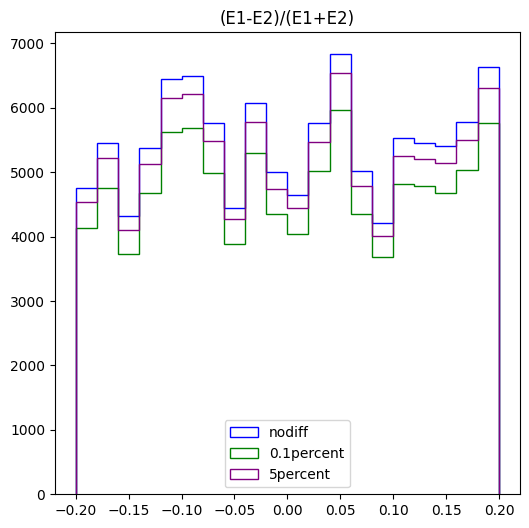

In [23]:
plt.figure(figsize=(6,6))
plt.hist(nodiff_full_df["asymmetry"], label="nodiff", color="blue", histtype="step", bins=20)
plt.hist(zero_one_full_df["asymmetry"], label="0.1percent", color="green", histtype="step", bins=20)
plt.hist(five_full_df["asymmetry"], label="5percent", color="purple", histtype="step", bins=20)
plt.title("(E1-E2)/(E1+E2)")
plt.legend()
plt.show()